# 4 - Teste

Este notebook executa a avaliacao final no conjunto de teste usando os artefatos produzidos nas etapas anteriores. A regra aqui e simples: nada de reescalar com informacao do teste e nada de reajustar hiperparametros com base nos resultados desta etapa.


## 1. Ambiente

Se necessario:

```python
# %pip install torch pyarrow pandas numpy matplotlib scikit-learn
```


In [7]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import (
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from torch import nn

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

#usa o mesmo criterio de device adotado no treino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


## 2. Carga de dados e configuracoes

Este notebook assume que `2-pre-processamento.ipynb` e `3-treino-validacao.ipynb` ja foram executados e que os artefatos estao presentes em `artifacts/`.


In [8]:
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {"versao1", "versao2"} else CURRENT_DIR
PREPROCESSED_DIR = PROJECT_ROOT / "artifacts" / "preprocessed"
MODELS_DIR = PROJECT_ROOT / "artifacts" / "models"

#recupera a configuracao salva junto com o modelo treinado
with (MODELS_DIR / "lstm_forecaster_standard_config.json").open() as fh:
    config = json.load(fh)

#carrega o conjunto de teste ja escalado com a estrategia usada no treino
test_df = pd.read_parquet(PREPROCESSED_DIR / f"test_{config['scaler_name']}.parquet")
print("Test shape:", test_df.shape)
config


Test shape: (3222, 6)


{'sequence_length': 30,
 'input_size': 6,
 'hidden_size': 64,
 'num_layers': 2,
 'dropout': 0.2,
 'scaler_name': 'standard',
 'max_epochs': 50,
 'patience': 7,
 'best_epoch': 13,
 'best_val_loss': 0.08053534757345915,
 'executed_epochs': 20}

## 3. Reconstrucao do modelo

O modelo precisa ser recriado com a mesma arquitetura usada no treino antes de carregar os pesos salvos.


In [9]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size: int, hidden_size: int = 64, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.head = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        output, _ = self.lstm(x)
        #mantem a mesma logica do treino usando o ultimo estado da janela
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


def create_sequences(dataframe: pd.DataFrame, sequence_length: int):
    #gera as janelas temporais do conjunto de teste
    values = dataframe.to_numpy(dtype=np.float32)
    sequences = []
    targets = []
    for start_idx in range(len(values) - sequence_length):
        end_idx = start_idx + sequence_length
        sequences.append(values[start_idx:end_idx])
        targets.append(values[end_idx])
    return (
        torch.tensor(np.stack(sequences), dtype=torch.float32),
        torch.tensor(np.stack(targets), dtype=torch.float32),
    )


X_test, y_test = create_sequences(test_df, sequence_length=config["sequence_length"])
model = LSTMForecaster(
    input_size=config["input_size"],
    hidden_size=config["hidden_size"],
    num_layers=config["num_layers"],
    dropout=config["dropout"],
).to(device)
#carrega os pesos aprendidos na etapa de treino
model.load_state_dict(torch.load(MODELS_DIR / "lstm_forecaster_standard.pt", map_location=device))
model.eval()

print(f"X_test: {tuple(X_test.shape)} | y_test: {tuple(y_test.shape)}")


X_test: (3192, 30, 6) | y_test: (3192, 6)


## 4. Inferencia, baseline e metricas

Nesta etapa, nao basta olhar apenas uma loss agregada. Para uma analise mais academica, vamos responder quatro perguntas:

1. o modelo supera um baseline ingênuo?
2. em quais variaveis ele erra mais?
3. os residuos estao centrados em zero ou mostram viés?
4. a previsao acompanha bem a forma da serie ou apenas suaviza demais?

O baseline escolhido aqui e o mais simples e importante em series temporais: a persistencia. Ele assume que o proximo valor sera igual ao ultimo valor observado na janela de entrada.


In [ ]:
#gera as previsoes do modelo e tambem um baseline de persistencia
with torch.no_grad():
    preds = model(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()
baseline_preds = X_test[:, -1, :].numpy() #persistencia: usa o ultimo valor da janela como previsao
feature_names = test_df.columns.tolist()


def evaluate_predictions(y_true_array: np.ndarray, y_pred_array: np.ndarray, label: str) -> dict:
    #agrega todas as features e todos os instantes para metricas globais
    flat_true = y_true_array.reshape(-1)
    flat_pred = y_pred_array.reshape(-1)
    mse = mean_squared_error(flat_true, flat_pred)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(flat_true, flat_pred)
    medae = median_absolute_error(flat_true, flat_pred)
    r2 = r2_score(y_true_array, y_pred_array, multioutput="uniform_average")
    evs = explained_variance_score(y_true_array, y_pred_array, multioutput="uniform_average")
    return {
        "modelo": label,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MedAE": medae,
        "R2_medio": r2,
        "ExplainedVariance_media": evs,
    }


global_metrics_df = pd.DataFrame(
    [
        evaluate_predictions(y_true, preds, "LSTM"),
        evaluate_predictions(y_true, baseline_preds, "Persistencia"),
    ]
)
global_metrics_df


,modelo,MSE,RMSE,MAE,MedAE,R2_medio,ExplainedVariance_media
0,LSTM,0.488696,0.699068,0.496597,0.307963,-8.382136,0.630183
1,Persistencia,0.002679,0.051761,0.021016,0.000000,0.997779,0.997780


### Como ler essas metricas

- `MAE`: erro absoluto medio. Quanto menor, melhor.
- `RMSE`: penaliza mais fortemente erros grandes. Quanto menor, melhor.
- `MedAE`: erro absoluto mediano. Ajuda a entender o erro "tipico" sem tanta sensibilidade a outliers.
- `R2`: mede quanta variabilidade do alvo foi explicada pela previsao.
  - perto de `1`: muito bom
  - perto de `0`: desempenho parecido com um preditor bem fraco
  - negativo: pior do que um referencial simples baseado na media
- `Explained Variance`: parecido com `R2`, mas focado na variabilidade explicada.

Como os dados estao na escala padronizada, o valor absoluto de `MAE` e `RMSE` deve ser lido com cuidado. Para iniciante, a comparacao com o baseline de persistencia costuma ser mais informativa do que olhar apenas o numero isolado da LSTM.


In [11]:
#resume o ganho da LSTM em relacao ao baseline de persistencia
lstm_row = global_metrics_df.loc[global_metrics_df["modelo"] == "LSTM"].iloc[0]
baseline_row = global_metrics_df.loc[global_metrics_df["modelo"] == "Persistencia"].iloc[0]

skill_summary_df = pd.DataFrame(
    {
        "metrica": ["RMSE", "MAE", "MedAE"],
        "LSTM": [lstm_row["RMSE"], lstm_row["MAE"], lstm_row["MedAE"]],
        "Persistencia": [baseline_row["RMSE"], baseline_row["MAE"], baseline_row["MedAE"]],
    }
)
skill_summary_df["melhora_percentual_da_LSTM"] = (
    (skill_summary_df["Persistencia"] - skill_summary_df["LSTM"]) / skill_summary_df["Persistencia"] * 100
)
skill_summary_df


,metrica,LSTM,Persistencia,melhora_percentual_da_LSTM
0,RMSE,0.699068,0.051761,-1250.575335
1,MAE,0.496597,0.021016,-2262.922295
2,MedAE,0.307963,0.000000,-inf


Se a LSTM nao supera a persistencia, isso e um sinal forte de que o modelo ainda nao extraiu uma dinamica temporal util.

### Resultado observado nesta execucao

- A LSTM ficou muito abaixo da persistencia nas metricas globais.
- `RMSE`: `0.6991` na LSTM contra `0.0518` na persistencia.
- `MAE`: `0.4966` na LSTM contra `0.0210` na persistencia.
- `R2 medio`: `-8.3821` na LSTM, enquanto a persistencia ficou em `0.9978`.
- A `Explained Variance` media da LSTM foi `0.6302`. Isso sugere que o modelo captou parte da variacao relativa do sinal, mas errou fortemente o nivel e a calibracao das previsoes.

Em uma leitura academica, esse contraste e muito importante. Um modelo pode parecer acompanhar parte do movimento da serie e ainda assim ser inadequado para previsao, porque o erro absoluto e o vies permanecem altos. Foi exatamente isso que ocorreu aqui.


In [12]:
#detalha o desempenho por feature para entender onde o modelo acerta e onde sofre
feature_rows = []
for feature_idx, feature_name in enumerate(feature_names):
    feature_true = y_true[:, feature_idx]
    feature_pred = preds[:, feature_idx]
    feature_baseline = baseline_preds[:, feature_idx]
    model_mse = mean_squared_error(feature_true, feature_pred)
    baseline_mse = mean_squared_error(feature_true, feature_baseline)
    model_rmse = float(np.sqrt(model_mse))
    baseline_rmse = float(np.sqrt(baseline_mse))
    model_mae = mean_absolute_error(feature_true, feature_pred)
    baseline_mae = mean_absolute_error(feature_true, feature_baseline)
    feature_rows.append(
        {
            "feature": feature_name,
            "model_mae": model_mae,
            "baseline_mae": baseline_mae,
            "mae_melhora_pct": (baseline_mae - model_mae) / baseline_mae * 100 if baseline_mae != 0 else np.nan,
            "model_rmse": model_rmse,
            "baseline_rmse": baseline_rmse,
            "rmse_melhora_pct": (baseline_rmse - model_rmse) / baseline_rmse * 100 if baseline_rmse != 0 else np.nan,
            "model_r2": r2_score(feature_true, feature_pred),
            "baseline_r2": r2_score(feature_true, feature_baseline),
            "model_bias": float(np.mean(feature_pred - feature_true)),
            "model_residual_std": float(np.std(feature_true - feature_pred)),
        }
    )

per_feature_metrics = pd.DataFrame(feature_rows).sort_values("model_rmse", ascending=False)
per_feature_metrics


,feature,model_mae,baseline_mae,mae_melhora_pct,model_rmse,baseline_rmse,rmse_melhora_pct,model_r2,baseline_r2,model_bias,model_residual_std
1,P-JUS-CKGL,1.425022,0.000230,-618604.267818,1.442351,0.000513,-280964.842649,-45.130844,0.999994,-1.425022,0.222909
0,P-ANULAR,0.693201,0.000281,-246402.254578,0.730976,0.000785,-92962.627097,-8.814942,0.999989,-0.693201,0.231943
3,P-TPT,0.371232,0.000958,-38660.411336,0.434334,0.001724,-25088.124160,0.858594,0.999998,0.361140,0.241296
5,T-TPT,0.231099,0.002970,-7681.661103,0.260940,0.008148,-3102.600441,0.846795,0.999851,0.224662,0.132727
4,T-JUS-CKP,0.135711,0.030399,-346.439668,0.175084,0.040760,-329.548310,0.971549,0.998458,-0.063832,0.163033
2,P-MON-CKP,0.123319,0.091260,-35.130109,0.173461,0.119764,-44.835330,0.975636,0.988385,0.064593,0.160986


### Como interpretar a tabela por feature

Essa tabela e importante porque um unico valor global pode esconder problemas localizados.

- `model_rmse` alto indica que aquela variavel e dificil para a rede.
- `rmse_melhora_pct` positivo indica que a LSTM foi melhor do que a persistencia.
- `model_r2` mostra a qualidade explicativa por feature.
- `model_bias` mostra viés medio:
  - positivo: o modelo tende a superestimar
  - negativo: o modelo tende a subestimar
- `model_residual_std` mostra o quanto os erros oscilam.

Para um estudante iniciante, este e um dos melhores pontos do notebook, porque obriga a sair do resultado agregado e pensar feature por feature.


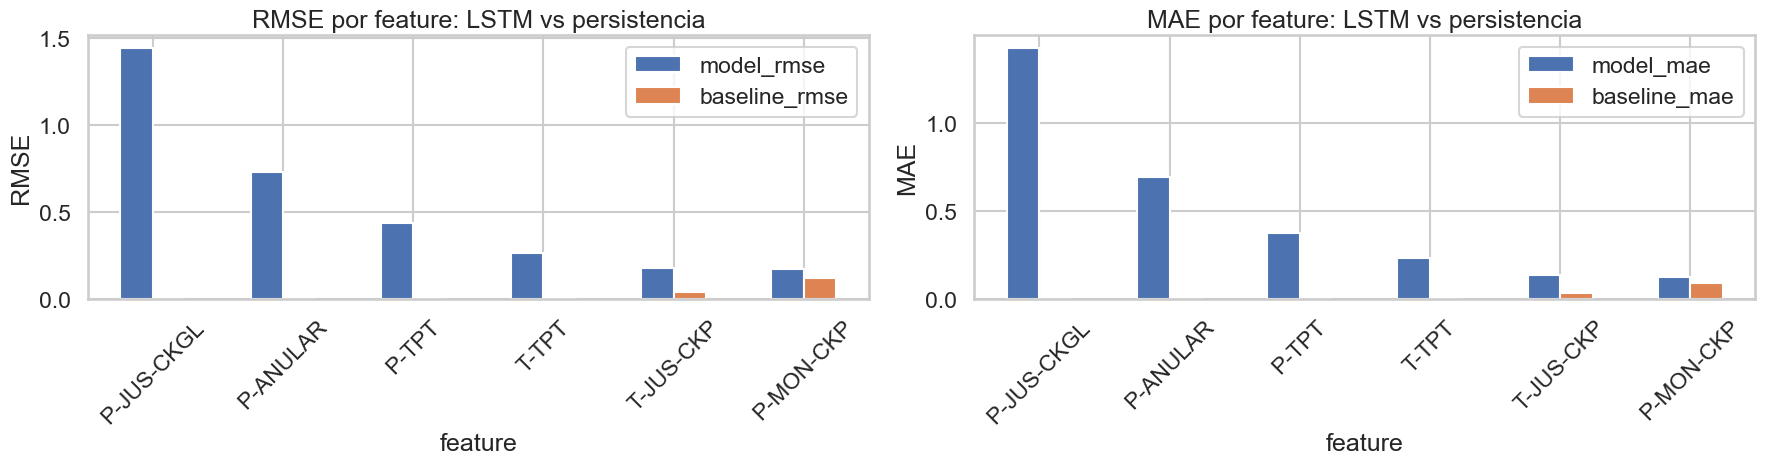

In [13]:
#compara graficamente LSTM e baseline nas metricas mais importantes
compare_plot_df = per_feature_metrics.set_index("feature")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
compare_plot_df[["model_rmse", "baseline_rmse"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("RMSE por feature: LSTM vs persistencia")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

compare_plot_df[["model_mae", "baseline_mae"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("MAE por feature: LSTM vs persistencia")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Se as barras da LSTM estiverem consistentemente abaixo das barras da persistencia, isso fortalece a interpretacao de que o modelo aprendeu padroes uteis. Quando ocorre o contrario, o grafico funciona como um argumento visual de que uma regra simples ja descreve melhor o problema.

### Leitura dos graficos desta execucao

- As barras da persistencia ficaram muito proximas de zero em quase todas as features, especialmente em `P-JUS-CKGL`, `P-ANULAR`, `P-TPT` e `T-TPT`.
- Isso indica que o proximo instante temporal e, na maior parte do tempo, muito parecido com o ultimo valor observado da janela.
- A maior degradacao da LSTM apareceu em `P-JUS-CKGL` e `P-ANULAR`, onde o erro do modelo ficou varias ordens de grandeza acima do baseline.
- Mesmo na feature mais favoravel, `P-MON-CKP`, a LSTM ainda nao superou a persistencia: `RMSE` de `0.1735` contra `0.1198`.

Para um estudante iniciante, a conclusao correta e: antes de tentar uma arquitetura mais sofisticada, e preciso mostrar que o modelo vence uma referencia simples. Neste experimento, isso ainda nao aconteceu.


## 5. Analise visual das previsoes e dos residuos

Agora vamos analisar os erros do jeito que um curso introdutorio de machine learning costuma recomendar: olhar a serie prevista, a relacao entre valor real e valor predito e o comportamento dos residuos.


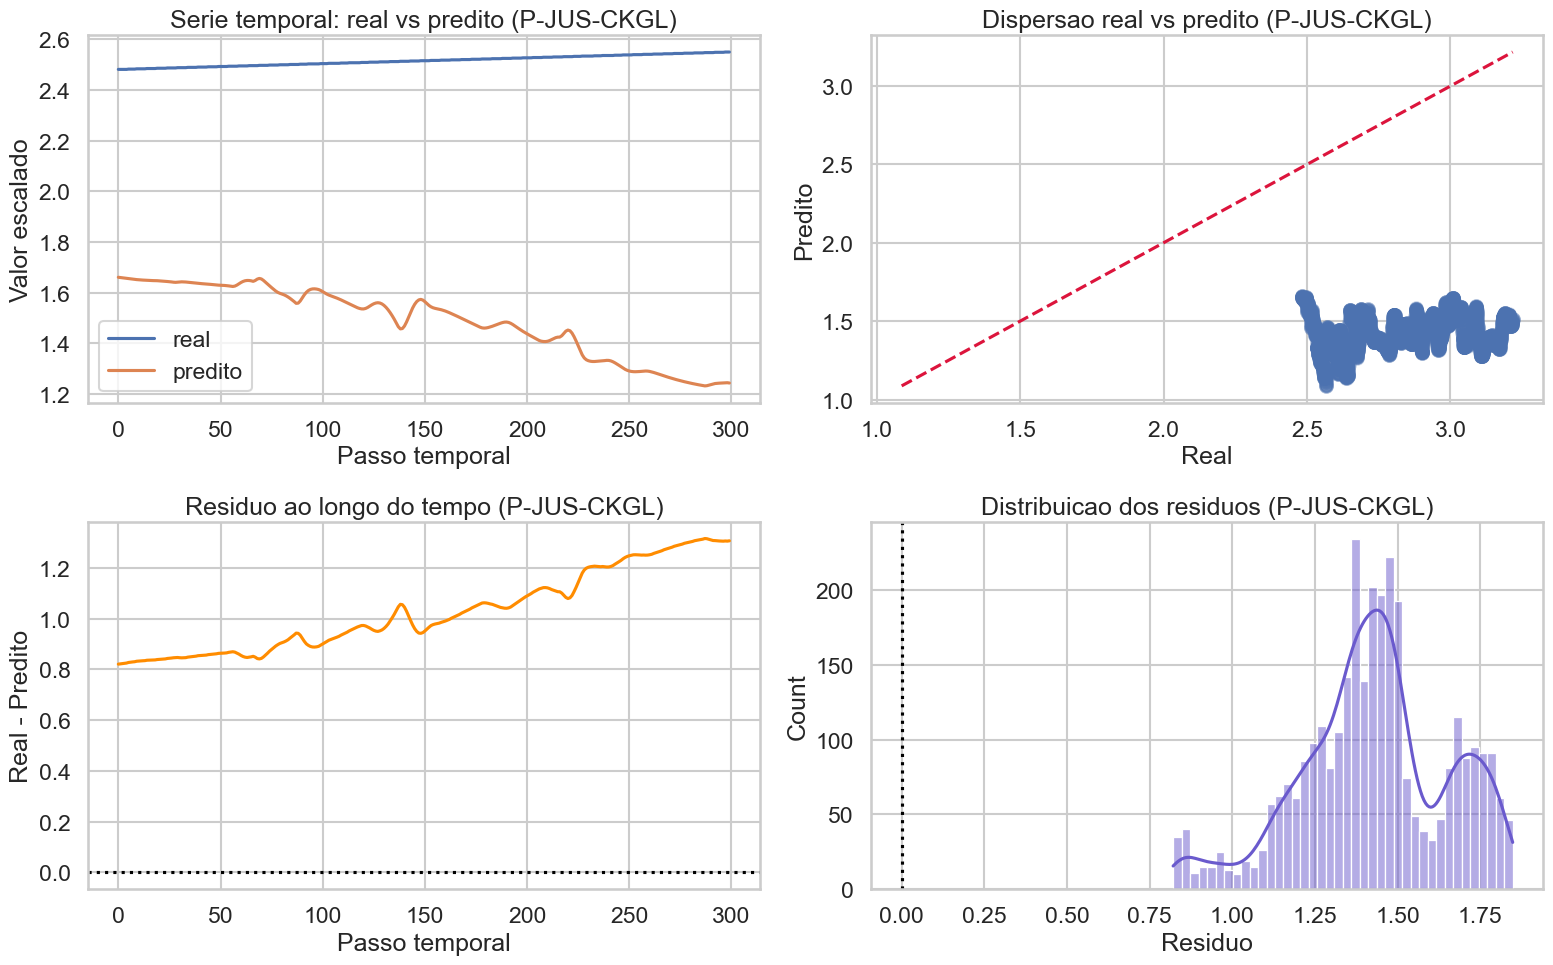

In [14]:
#escolhe automaticamente a feature mais dificil para uma inspecao mais critica
feature_to_plot = per_feature_metrics.iloc[0]["feature"]
feature_idx = feature_names.index(feature_to_plot)

plot_df = pd.DataFrame(
    {
        "real": y_true[:, feature_idx],
        "predito": preds[:, feature_idx],
    }
)
plot_df["residuo"] = plot_df["real"] - plot_df["predito"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

#compara a forma da serie real com a serie prevista
plot_df.iloc[:300][["real", "predito"]].plot(ax=axes[0, 0], title=f"Serie temporal: real vs predito ({feature_to_plot})")
axes[0, 0].set_xlabel("Passo temporal")
axes[0, 0].set_ylabel("Valor escalado")

#mostra se os pontos ficam proximos da reta ideal y=x
axes[0, 1].scatter(plot_df["real"], plot_df["predito"], alpha=0.3)
min_axis = min(plot_df["real"].min(), plot_df["predito"].min())
max_axis = max(plot_df["real"].max(), plot_df["predito"].max())
axes[0, 1].plot([min_axis, max_axis], [min_axis, max_axis], color="crimson", linestyle="--")
axes[0, 1].set_title(f"Dispersao real vs predito ({feature_to_plot})")
axes[0, 1].set_xlabel("Real")
axes[0, 1].set_ylabel("Predito")

#mostra se os erros se mantem centrados ou apresentam regioes problematicas
axes[1, 0].plot(plot_df["residuo"].iloc[:300], color="darkorange")
axes[1, 0].axhline(0, color="black", linestyle=":")
axes[1, 0].set_title(f"Residuo ao longo do tempo ({feature_to_plot})")
axes[1, 0].set_xlabel("Passo temporal")
axes[1, 0].set_ylabel("Real - Predito")

#observa a distribuicao dos residuos
sns.histplot(plot_df["residuo"], bins=40, kde=True, ax=axes[1, 1], color="slateblue")
axes[1, 1].axvline(0, color="black", linestyle=":")
axes[1, 1].set_title(f"Distribuicao dos residuos ({feature_to_plot})")
axes[1, 1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()


### Como interpretar esses quatro graficos

- A serie temporal mostra se o modelo acompanha o nivel e a direcao do sinal ao longo do tempo.
- A dispersao `real x predito` mostra o quao perto os pontos ficam da reta ideal `y = x`.
- O grafico de residuos mostra se o erro fica centrado em zero ou se existe vies sistematico.
- O histograma ajuda a ver se os residuos parecem ruido aleatorio ou se ficam deslocados para um lado.

### Leitura do caso mais dificil: `P-JUS-CKGL`

- Na serie temporal, o sinal real permanece alto e levemente crescente, por volta de `2.48` ate `2.56`, enquanto a previsao da LSTM fica muito abaixo disso, caindo de aproximadamente `1.66` para `1.24`.
- Na dispersao, a nuvem de pontos aparece quase toda abaixo da reta ideal. Isso significa subpredicao sistematica: quando o valor real cresce, o modelo continua prevendo um patamar muito menor.
- No grafico de residuos, o erro permanece positivo e ainda aumenta ao longo do tempo, saindo de algo proximo de `0.8` para cerca de `1.3`. Isso mostra que o problema nao e apenas variancia alta; existe um vies persistente.
- No histograma, os residuos ficam concentrados longe de zero, em torno de `1.4`, o que reforca que o erro e estrutural e nao um ruido pequeno distribuido ao redor do valor correto.

Academicamente, esse conjunto de evidencias e forte: o modelo nao apenas erra em alguns pontos, ele esta mal calibrado para essa feature e aprende uma dinamica com nivel incorreto.


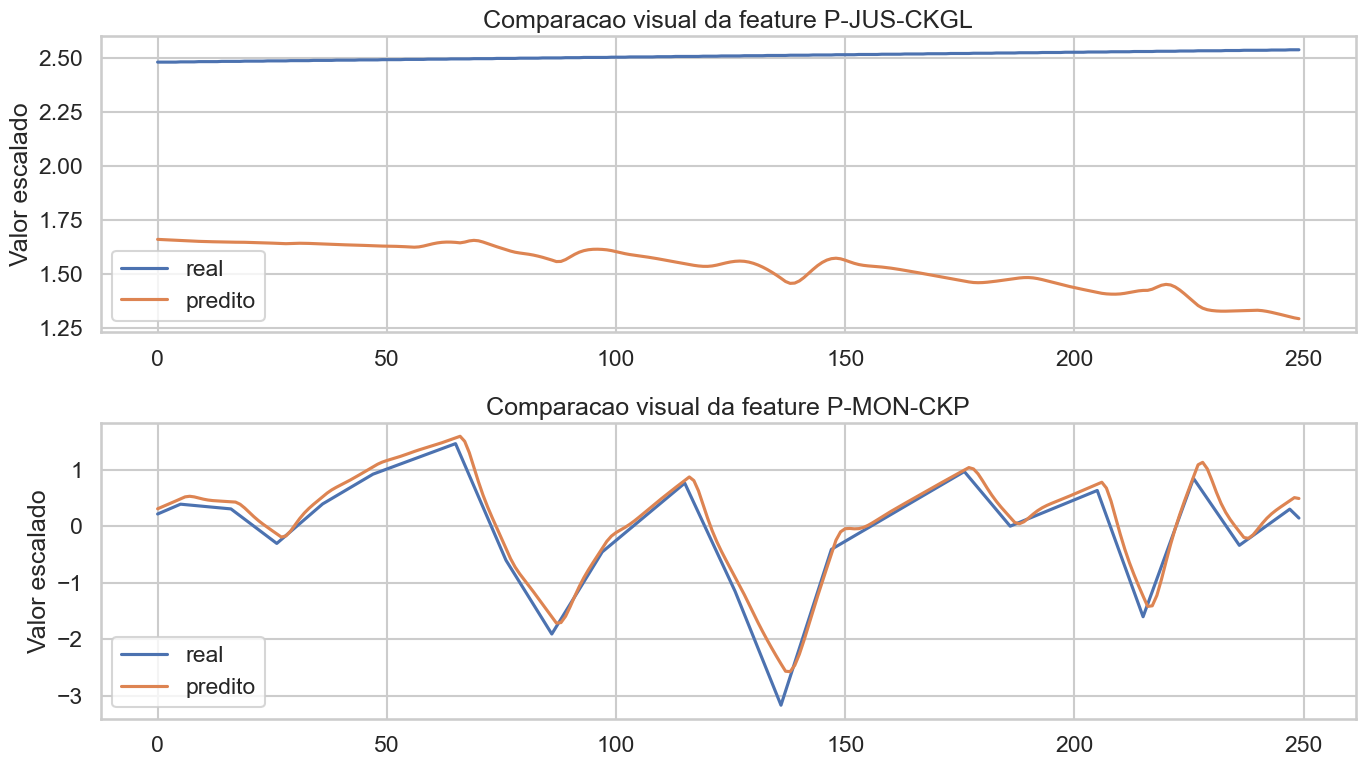

In [15]:
#contrasta a feature mais dificil com a mais facil segundo o RMSE da LSTM
worst_feature = per_feature_metrics.iloc[0]["feature"]
best_feature = per_feature_metrics.iloc[-1]["feature"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)
for ax, feature_name in zip(axes, [worst_feature, best_feature]):
    idx = feature_names.index(feature_name)
    local_df = pd.DataFrame(
        {
            "real": y_true[:, idx],
            "predito": preds[:, idx],
        }
    )
    local_df.iloc[:250].plot(ax=ax, title=f"Comparacao visual da feature {feature_name}")
    ax.set_ylabel("Valor escalado")

plt.tight_layout()
plt.show()


Essa comparacao entre melhor e pior feature ajuda a perceber que um mesmo modelo pode ser razoavel para algumas variaveis e inadequado para outras.

### O que os dois graficos mostram nesta execucao

- Em `P-JUS-CKGL`, a LSTM falha em dois aspectos ao mesmo tempo: nao acompanha o nivel do sinal e ainda segue uma inclinacao oposta ao comportamento real em parte da janela observada.
- Em `P-MON-CKP`, que foi a feature menos problematica, a rede consegue seguir melhor a forma geral da serie e ate acompanhar mudancas de sinal.
- Mesmo assim, a previsao ainda suaviza picos e vales, o que e um comportamento tipico de modelos treinados com `MSE`: eles tendem a aproximar a media local e erram mais nos extremos.

Esse contraste e didatico porque mostra que nao basta olhar apenas uma media global. A media pode esconder o fato de que algumas variaveis estao quase resolvidas, enquanto outras ainda derrubam o desempenho total do modelo.


## 6. Diagnostico academico do teste

Por fim, vamos sintetizar a avaliacao em uma tabela e em um texto interpretativo. O objetivo aqui e treinar a leitura critica de resultados, nao apenas gerar numeros.


In [16]:
#resume residuos e gera um diagnostico textual mais orientado a estudo
residual_rows = []
for feature_idx, feature_name in enumerate(feature_names):
    residual = y_true[:, feature_idx] - preds[:, feature_idx]
    residual_rows.append(
        {
            "feature": feature_name,
            "residuo_medio": float(np.mean(residual)),
            "residuo_mediano": float(np.median(residual)),
            "residuo_std": float(np.std(residual)),
            "residuo_p05": float(np.percentile(residual, 5)),
            "residuo_p95": float(np.percentile(residual, 95)),
        }
    )

residual_summary_df = pd.DataFrame(residual_rows).sort_values("residuo_std", ascending=False)
residual_summary_df


,feature,residuo_medio,residuo_mediano,residuo_std,residuo_p05,residuo_p95
3,P-TPT,-0.361140,-0.434745,0.241296,-0.684166,0.038610
0,P-ANULAR,0.693201,0.801371,0.231943,0.310186,0.964861
1,P-JUS-CKGL,1.425022,1.427404,0.222909,1.015616,1.790444
4,T-JUS-CKP,0.063832,0.073345,0.163033,-0.188091,0.286742
2,P-MON-CKP,-0.064593,-0.046502,0.160986,-0.345923,0.165481
5,T-TPT,-0.224662,-0.222211,0.132727,-0.443493,-0.028989


In [17]:
#gera uma leitura qualitativa do teste a partir dos numeros globais e do baseline
overall_rmse_gain = float(
    (baseline_row["RMSE"] - lstm_row["RMSE"]) / baseline_row["RMSE"] * 100
)
overall_mae_gain = float(
    (baseline_row["MAE"] - lstm_row["MAE"]) / baseline_row["MAE"] * 100
)
overall_r2 = float(lstm_row["R2_medio"])
worst_feature_name = per_feature_metrics.iloc[0]["feature"]
best_feature_name = per_feature_metrics.iloc[-1]["feature"]

if overall_rmse_gain > 20 and overall_r2 > 0.5:
    final_assessment = "desempenho bom para um baseline academico"
elif overall_rmse_gain > 5 and overall_r2 > 0:
    final_assessment = "desempenho razoavel, com aprendizado util mas ainda distante de uma solucao forte"
else:
    final_assessment = "desempenho fraco, com pouco ganho sobre referencias simples"

diagnosis_df = pd.DataFrame(
    {
        "aspecto": [
            "avaliacao_final",
            "ganho_global_rmse_vs_persistencia_pct",
            "ganho_global_mae_vs_persistencia_pct",
            "r2_medio_da_lstm",
            "feature_mais_dificil",
            "feature_mais_facil",
        ],
        "valor": [
            final_assessment,
            overall_rmse_gain,
            overall_mae_gain,
            overall_r2,
            worst_feature_name,
            best_feature_name,
        ],
    }
)
diagnosis_df


,aspecto,valor
0,avaliacao_final,"desempenho fraco, com pouco ganho sobre refere..."
1,ganho_global_rmse_vs_persistencia_pct,-1250.575335
2,ganho_global_mae_vs_persistencia_pct,-2262.922295
3,r2_medio_da_lstm,-8.382136
4,feature_mais_dificil,P-JUS-CKGL
5,feature_mais_facil,P-MON-CKP


### Leitura final para estudante iniciante

Uma analise academica madura do teste nao pergunta apenas "qual foi o RMSE?". Ela pergunta:

- o modelo venceu um baseline simples?
- o ganho foi pequeno ou relevante?
- esse ganho apareceu em todas as features ou so em algumas?
- os residuos mostram vies sistematico?
- o modelo acompanha a forma da serie ou apenas suaviza o sinal?

Aplicando essas perguntas ao experimento atual, a resposta e clara:

- Nao, a LSTM nao venceu o baseline. A persistencia foi amplamente superior.
- O desempenho nao foi apenas "um pouco pior"; ele foi muito pior nas metricas globais e em todas as features.
- O pior comportamento apareceu em `P-JUS-CKGL` e `P-ANULAR`, que concentraram grande parte do erro.
- Os residuos nao ficaram centrados em zero em varias features, o que indica vies sistematico e nao apenas ruido aleatorio.
- A rede parece captar parte da forma do sinal em variaveis como `P-MON-CKP`, mas nao consegue calibrar corretamente o nivel das previsoes.

Um ponto interessante para interpretar com profundidade e a combinacao entre `Explained Variance = 0.6302` e `R2 medio = -8.3821`. Isso sugere que o modelo captou alguma direcao de variacao, mas falhou fortemente no alinhamento quantitativo. Em outras palavras: a rede as vezes "entende para onde o sinal vai", mas ainda erra muito "quanto vale" esse sinal.

Por isso, a conclusao correta nao e que a LSTM "nao serve". A conclusao correta e que esta primeira configuracao ainda nao e competitiva para este problema e precisa de uma segunda iteracao metodologicamente melhor desenhada.


## 7. Fechamento e melhorias para a versao 2

Como experimento diagnostico, este teste foi util: ele mostrou que o pipeline funciona de ponta a ponta, mas a configuracao atual ainda nao supera uma referencia muito simples. Para uma segunda versao do modelo, as melhorias mais promissoras sao:

- usar a persistencia como referencia obrigatoria de validacao: o modelo so deve ser promovido se superar esse baseline de forma consistente
- prever o `delta` entre `t30` e `t31`, ou o residuo em relacao a persistencia, em vez de prever diretamente o valor absoluto
- tratar as features de forma mais cuidadosa, com perda ponderada por variavel, modelos por grupo de sensores ou ate modelos univariados iniciais
- testar novos hiperparametros, principalmente `sequence_length`, `hidden_size`, `learning_rate`, numero de camadas e `dropout`
- comparar a LSTM com baselines adicionais, como regressao linear, `MLP` e `GRU`, para verificar se a complexidade extra realmente traz ganho
- ampliar o conjunto de treino com mais arquivos e mais regimes de operacao do 3W, reduzindo o risco de o modelo aprender um padrao muito especifico de uma unica serie
- revisar a normalizacao e interpretar tambem os resultados na escala original, porque parte do erro atual pode estar associada a vies de calibracao por feature

Se a versao 2 conseguir reduzir o vies sistematico nas variaveis de pressao e ao menos se aproximar da persistencia em todas as features, o projeto ja dara um salto importante de qualidade metodologica.
